In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from pathlib import Path

from WindGym.wind_env_multi import WindFarmEnvMulti
from py_wake.examples.data.hornsrev1 import V80

/home/tobas/Workspaces/windgym-experiments/.conda-env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
x_pos = [100, 500, 900]
y_pos = [0, 0, 0]

env = WindFarmEnvMulti(
    turbine=V80(),
    x_pos=x_pos,
    y_pos=y_pos,
    n_passthrough=10,
    turbtype="Random",
    config=Path(__file__).parent / "EnvConfigs/Env1.yaml" if "__file__" in dir() else "EnvConfigs/Env1.yaml",
    render_mode=None,
)

In [3]:
N_RUNS = 3
N_STEPS = 10

run_data = []  # list of lists: run_data[run][step] = flow field dict

for run in range(N_RUNS):
    observations, info = env.reset()
    step_data = []

    for step in range(N_STEPS):
        actions = {agent: env.action_space(agent).sample() for agent in env.agents}
        observations, rewards, dones, truncations, infos = env.step(actions)

        probes = env.probes if hasattr(env, "probes") else None
        ff = env.renderer.get_flow_field(
            env.fs, probes=probes, turbine=env.turbine, fix_turbines=False
        )
        ff["probe_readings"] = [float(p.read()) for p in ff["probes"]]
        step_data.append(ff)

        if all(dones.values()) or all(truncations.values()):
            break

    run_data.append(step_data)
    print(f"Run {run + 1} done — {len(step_data)} steps  WD={step_data[-1]['wd']:.0f}°")

Run 1 done — 10 steps  WD=267°
Run 2 done — 10 steps  WD=282°
Run 3 done — 10 steps  WD=284°


Saved animation to wind_farm_animation.gif


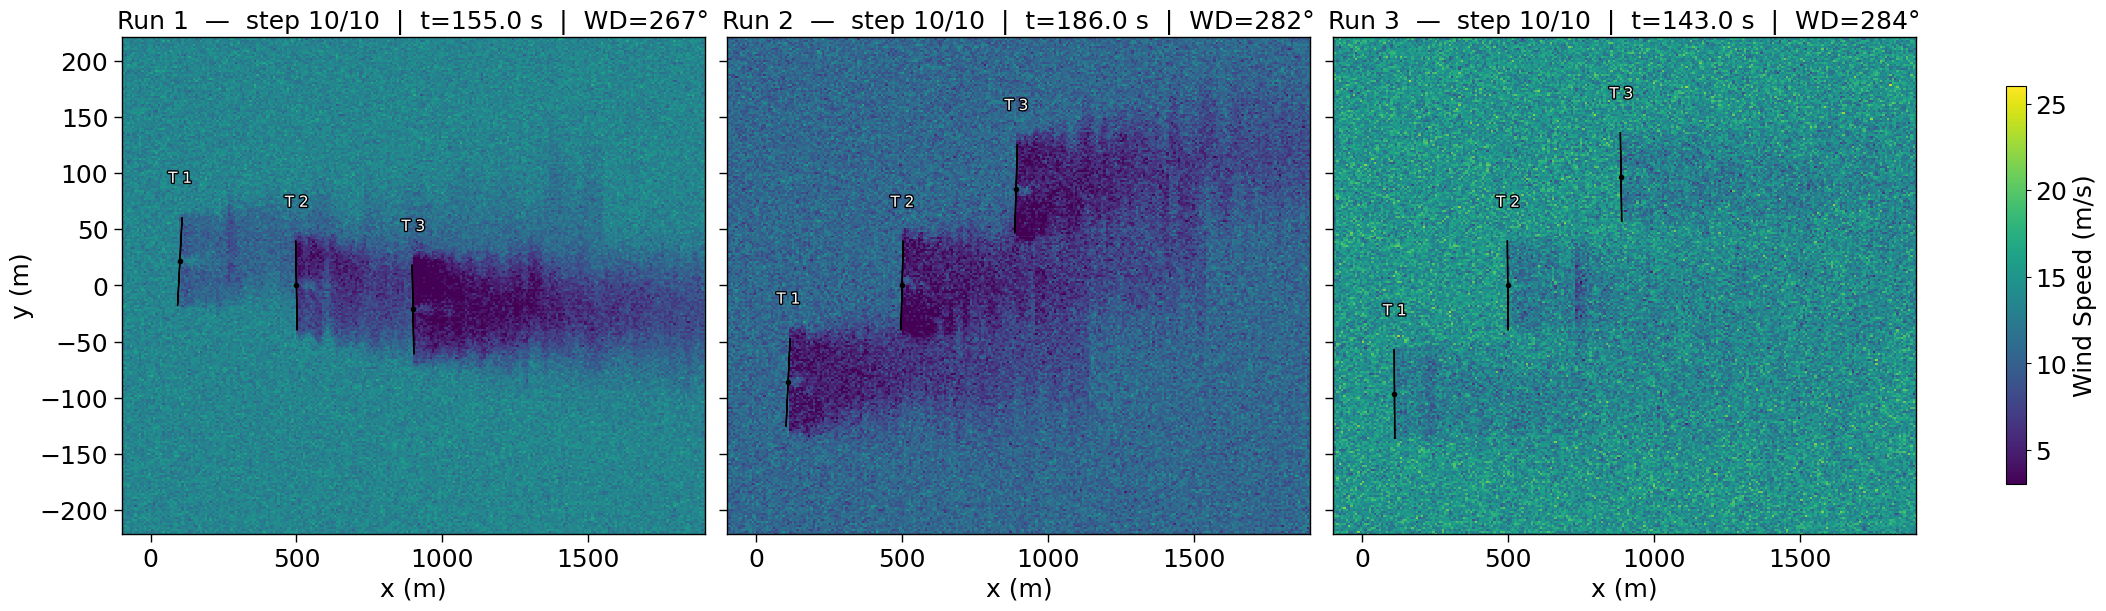

In [4]:
import matplotlib.patheffects as pe
from matplotlib.animation import FuncAnimation, PillowWriter

AXES_FONTSIZE = 18   # tick labels, axis labels, titles
TURB_FONTSIZE = 11   # turbine index labels
PROBE_FONTSIZE = 8   # probe speed text


def draw_turbines(ax, ff, fontsize=TURB_FONTSIZE):
    x_turb, y_turb = ff["x_turb"], ff["y_turb"]
    R = ff["diameter"] / 2
    for ii, (x_, y_, r, yaw_, tilt_) in enumerate(
        zip(x_turb, y_turb, R, ff["yaw_plot"], ff["tilt"])
    ):
        ax.add_artist(Ellipse(
            (x_, y_), 2 * r * np.sin(np.deg2rad(tilt_)), 2 * r,
            angle=yaw_, ec="k", fc="None"
        ))
        ax.plot(x_, y_, ".", color="k")
        txt = ax.annotate(
            f"T {ii + 1}", (x_ - r, y_ + r * 1.75),
            fontsize=fontsize, color="white"
        )
        txt.set_path_effects([pe.Stroke(linewidth=2, foreground="black"), pe.Normal()])


def draw_probes(ax, ff, fontsize=PROBE_FONTSIZE):
    for (x, y), angle, speed, probe in zip(
        ff["probe_positions"], ff["probe_inflow_angles"],
        ff["probe_readings"], ff["probes"]
    ):
        color = "red" if probe.probe_type.upper() == "WS" else "blue"
        ax.scatter(x, y, color=color, s=25, marker="o")
        ax.text(
            x + 5, y + 5, f"{speed:.2f} m/s",
            fontsize=fontsize, color="black",
            bbox=dict(facecolor="none", alpha=0.6, edgecolor="none")
        )
        arrow_length = speed * 5
        ax.arrow(
            x, y,
            arrow_length * np.cos(angle), arrow_length * np.sin(angle),
            width=1.5, head_width=5.0, head_length=7.0,
            fc=color, ec=color, alpha=0.8, length_includes_head=True
        )


def wind_array(ff):
    return np.asarray(ff["uvw"][0]).T


# Shared colorbar range across all runs and steps
all_max = max(wind_array(ff).max() for steps in run_data for ff in steps)
vmax = np.ceil(all_max / 2.0) * 2.0
vmin = 3.0

n_steps_per_run = [len(steps) for steps in run_data]
n_frames = max(n_steps_per_run)

fig, axes = plt.subplots(
    1, N_RUNS,
    figsize=(7 * N_RUNS, 6),
    sharey=True,
    layout="constrained"
)

# Initial frame
meshes = []
for i, (ax, steps) in enumerate(zip(axes, run_data)):
    ff = steps[0]
    mesh = ax.pcolormesh(
        np.asarray(ff["x"]), np.asarray(ff["y"]), wind_array(ff),
        shading="nearest", cmap="viridis", vmin=vmin, vmax=vmax
    )
    meshes.append(mesh)
    ax.set_xlim(np.asarray(ff["x"]).min(), np.asarray(ff["x"]).max())
    ax.set_ylim(np.asarray(ff["y"]).min(), np.asarray(ff["y"]).max())
    ax.set_xlabel("x (m)", fontsize=AXES_FONTSIZE)
    ax.tick_params(which="major", width=1.0, length=6, labelsize=AXES_FONTSIZE)
    for spine in ax.spines.values():
        spine.set_linewidth(1.0)

axes[0].set_ylabel("y (m)", fontsize=AXES_FONTSIZE)
cbar = fig.colorbar(meshes[0], ax=axes, label="Wind Speed (m/s)", shrink=0.8)
cbar.ax.tick_params(labelsize=AXES_FONTSIZE)
cbar.set_label("Wind Speed (m/s)", fontsize=AXES_FONTSIZE)

# Per-axis artist containers cleared each frame
turb_artists = [[] for _ in range(N_RUNS)]
probe_artists = [[] for _ in range(N_RUNS)]
titles = [ax.set_title("", fontsize=AXES_FONTSIZE) for ax in axes]


def update(frame):
    for i, (ax, steps, mesh) in enumerate(zip(axes, run_data, meshes)):
        step_idx = min(frame, len(steps) - 1)
        ff = steps[step_idx]

        mesh.set_array(wind_array(ff).ravel())

        for art in turb_artists[i] + probe_artists[i]:
            art.remove()
        turb_artists[i].clear()
        probe_artists[i].clear()

        # Turbines
        x_turb, y_turb = ff["x_turb"], ff["y_turb"]
        R = ff["diameter"] / 2
        for ii, (x_, y_, r, yaw_, tilt_) in enumerate(
            zip(x_turb, y_turb, R, ff["yaw_plot"], ff["tilt"])
        ):
            e = Ellipse(
                (x_, y_), 2 * r * np.sin(np.deg2rad(tilt_)), 2 * r,
                angle=yaw_, ec="k", fc="None"
            )
            ax.add_artist(e)
            turb_artists[i].append(e)
            pt, = ax.plot(x_, y_, ".", color="k")
            turb_artists[i].append(pt)
            txt = ax.annotate(
                f"T {ii + 1}", (x_ - r, y_ + r * 1.75), fontsize=TURB_FONTSIZE, color="white"
            )
            txt.set_path_effects([pe.Stroke(linewidth=2, foreground="black"), pe.Normal()])
            turb_artists[i].append(txt)

        # Probes
        for (x, y), angle, speed, probe in zip(
            ff["probe_positions"], ff["probe_inflow_angles"],
            ff["probe_readings"], ff["probes"]
        ):
            color = "red" if probe.probe_type.upper() == "WS" else "blue"
            sc = ax.scatter(x, y, color=color, s=25, marker="o")
            probe_artists[i].append(sc)
            txt = ax.text(
                x + 5, y + 5, f"{speed:.2f} m/s", fontsize=PROBE_FONTSIZE, color="black",
                bbox=dict(facecolor="none", alpha=0.6, edgecolor="none")
            )
            probe_artists[i].append(txt)
            arrow_length = speed * 5
            arr = ax.arrow(
                x, y,
                arrow_length * np.cos(angle), arrow_length * np.sin(angle),
                width=1.5, head_width=5.0, head_length=7.0,
                fc=color, ec=color, alpha=0.8, length_includes_head=True
            )
            probe_artists[i].append(arr)

        titles[i].set_text(
            f"Run {i + 1}  —  step {step_idx + 1}/{len(steps)}  |  "
            f"t={ff['time']:.1f} s  |  WD={ff['wd']:.0f}°"
        )

    return meshes + [a for arts in turb_artists + probe_artists for a in arts] + titles


anim = FuncAnimation(fig, update, frames=n_frames, interval=500, blit=False)

GIF_PATH = "wind_farm_animation.gif"
anim.save(GIF_PATH, writer=PillowWriter(fps=2))
print(f"Saved animation to {GIF_PATH}")

plt.show()